# Lab 6: Unsupervised Learning - Association Rules and Clustering

## Part A: Association Rule Mining

### 1. Introduction to Association Rules
Association rule mining is a method for discovering interesting relations between variables in large databases.

### Key Concepts:
- **Frequent Itemsets**: Items that appear together often.
- **Apriori Principle**: If an itemset is frequent, all its subsets must also be frequent.

### Metrics Explained (Layman's Terms):
1. **Support**: **(Popularity Score)** - How often do these items appear in all transactions? (e.g., 0.6 means 60% of customers bought this combo).
2. **Confidence**: **(Reliability Score)** - If a customer buys Item A, how likely (0% to 100%) are they to also buy Item B?
3. **Lift**: **(Connection Score)** - Is the relationship real or a coincidence?
    - *Lift > 1*: Real connection (A helps sell B).
    - *Lift = 1*: No connection (Random chance).
    - *Lift < 1*: Coincidence (Both are popular on their own, but don't actually help each other).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_moons, make_blobs

# Set plot style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 2. Apriori Algorithm Implementation
Using the grocery shop dataset from the slides.

In [5]:
# Dataset from Chapter 6 slides
dataset = [
    ['Bread', 'Butter', 'Milk'],
    ['Bread', 'Milk'],
    ['Butter', 'Milk'],
    ['Bread', 'Butter'],
    ['Bread', 'Milk']
]

te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_trans, min_support=0.5, use_colnames=True)
print("Frequent Itemsets:")
print(frequent_itemsets)

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)
print("\nAssociation Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

Frequent Itemsets:
   support       itemsets
0      0.8        (Bread)
1      0.6       (Butter)
2      0.8         (Milk)
3      0.6  (Bread, Milk)

Association Rules:
  antecedents consequents  support  confidence    lift
0     (Bread)      (Milk)      0.6        0.75  0.9375
1      (Milk)     (Bread)      0.6        0.75  0.9375


### 3. Layman's Analysis of Results

#### **Frequent Itemsets Analysis:**
- **Bread (0.8)**: 80% of customers bought Bread. It's the most popular item.
- **Milk (0.8)**: Also 80%. Another top-seller.
- **(Bread, Milk) (0.6)**: 60% of all carts had both. This is a very common pair.

#### **Association Rules Analysis:**
- **Rule: (Bread) -> (Milk)**:
  - **Confidence (0.75)**: If someone picks up Bread, there is a **75% chance** they will also pick up Milk. This looks like a strong prediction.
  - **Lift (0.9375)**: Even though confidence is high, the Lift is **less than 1**. This means the connection is likely a **coincidence**. Because both Bread and Milk are so popular individually (80% each), people would likely buy them together anyway, even if there was no relationship between them. The Bread doesn't actually "push" customers to buy Milk.

## Part B: Cluster Analysis

### 4. K-Means Clustering

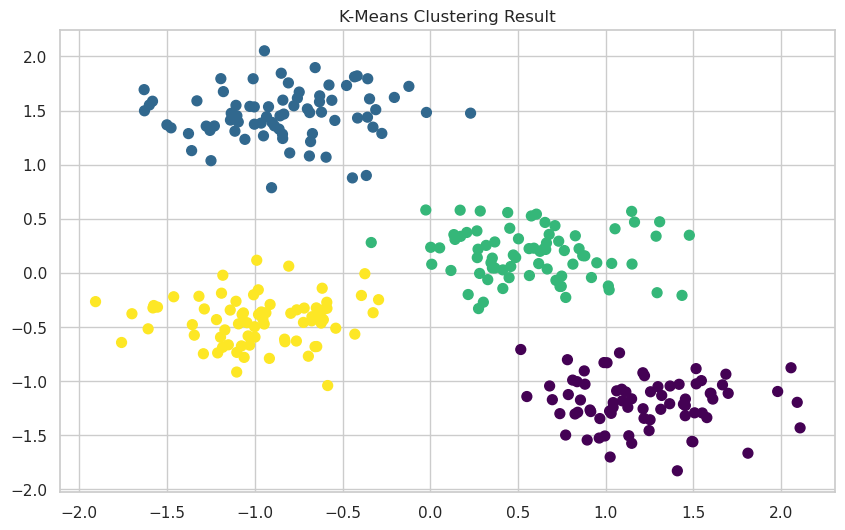

In [6]:
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.title("K-Means Clustering Result")
plt.show()

### 5. Hierarchical Clustering

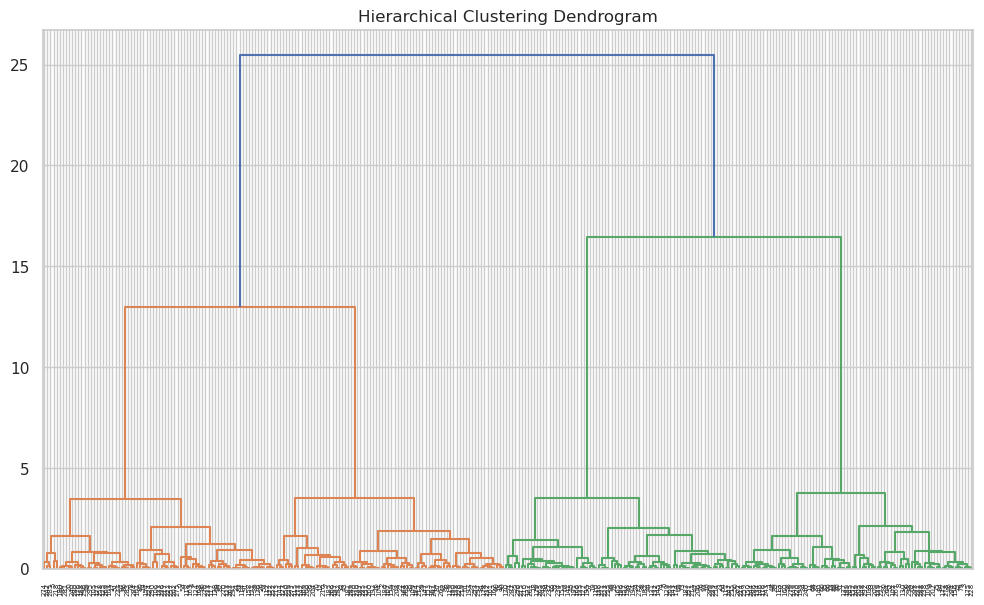

In [7]:
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(12, 7))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()

### 6. Density-Based Clustering (DBSCAN)

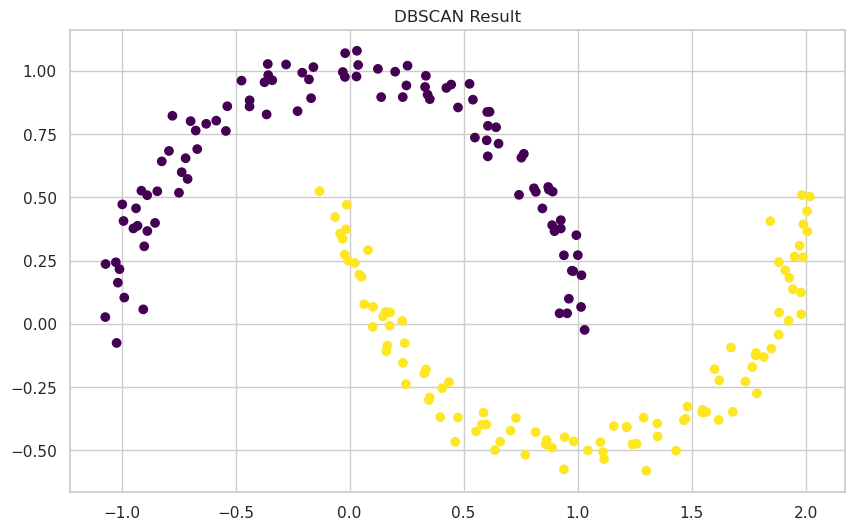

In [8]:
X_moon, _ = make_moons(n_samples=200, noise=0.05, random_state=0)
dbscan = DBSCAN(eps=0.3, min_samples=5)
y_dbscan = dbscan.fit_predict(X_moon)
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=y_dbscan, cmap='viridis')
plt.title("DBSCAN Result")
plt.show()

### 7. Exercises
1. **Tuning**: Change `min_support` to 0.4. Does our Lift score for Bread and Milk improve?
2. **Visualization**: Try to plot the association rules using a network graph or a scatter plot of (Support vs Confidence).